# Diffusion Models Session – Part 2: Conditioning & Guidance

**Alejandro Lancho Serrano, Vanessa Gómez Verdejo, Pablo Martínez Olmos, Emilio Parrado Hernández**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~emipar/BBVA/INTRO/img/logo_uc3m_foot.jpg' width=400 />

## Table of Contents
1. [Recap & Objectives](#recap-objectives)
2. [Setup](#setup)
3. [Conditioning with Labels](#conditioning-labels)
5. [Training the Conditioned Model](#training-conditioned)
6. [Sampling with Conditioning](#sampling-conditioned)
7. [Visualization](#visualization)


## Recap & Objectives <a id="recap-objectives"></a>

Part 1 built an unconditional DDPM on sprites. Here we add a **class label** $c$ so we can ask for a specific sprite type. The forward process, loss, and reverse step are unchanged; only the network gains an extra input. The slides and notes carry the theory; this notebook is the implementation companion.


## Conditioning: generating a chosen class

Conditioning adds a label $c$ and asks for the missing $x_0$ **given that label**: the network now estimates $\mathbb{E}[x_0\mid x_t,c]$ instead of $\mathbb{E}[x_0\mid x_t]$. The label shrinks the set of clean images that could explain $x_t$, so the guess is sharper. We keep the same sprites dataset (each image carries a class label) and the same DDPM machinery; the only change is that the denoiser takes $c$ as an extra input.


### Seeing conditioning in 2D

The two-moons toy from Part 1 makes the point. Treat each moon as a class. Fix one noised point that came from class 1 (the star) and shade each clean point by how plausibly it could have produced it. Without a label, the plausible clean points spread across both classes; with the label, only that class remains. Conditioning is exactly this narrowing of the missing-$x_0$ guess, $\mathbb{E}[x_0\mid x_t]\to\mathbb{E}[x_0\mid x_t,c]$.


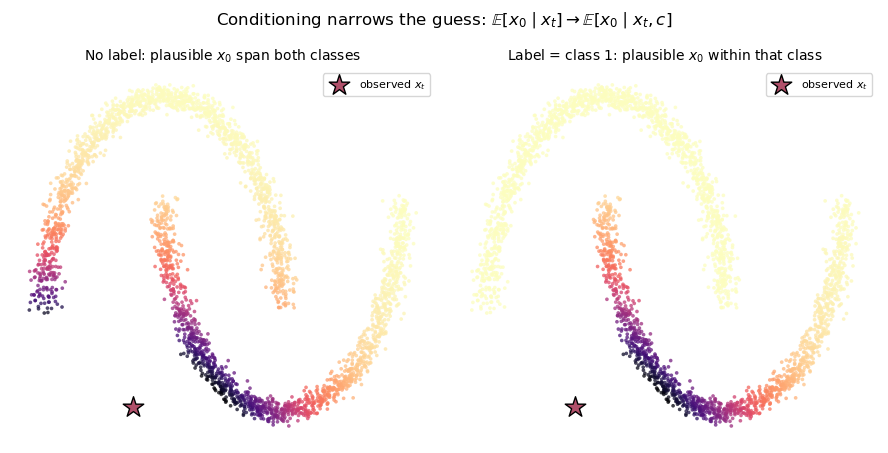

In [1]:
# --- self-contained 2D illustration (numpy + matplotlib only; does not touch the sprite model) ---
import numpy as np
import matplotlib.pyplot as plt

rng_toy = np.random.default_rng(7)

def two_moons(n, noise=0.08, rng=None):
    rng = rng or np.random.default_rng()
    n1, n2 = n // 2, n - n // 2
    a = np.pi * rng.random(n1); m1 = np.stack([np.cos(a), np.sin(a)], 1)
    b = np.pi * rng.random(n2); m2 = np.stack([1 - np.cos(b), 0.5 - np.sin(b)], 1)
    X = np.concatenate([m1, m2], 0)
    y = np.concatenate([np.zeros(n1, int), np.ones(n2, int)])      # two classes, one per moon
    X = (X - X.mean(0)) / X.std(0) * 1.3
    return (X + noise * rng.normal(size=X.shape)).astype(float), y

X0_toy, y_toy = two_moons(3000, rng=rng_toy)
T_toy = 150
beta_toy = np.linspace(5e-4, 0.08, T_toy)
abar_toy = np.cumprod(1.0 - beta_toy)

def q_sample_toy(x0, t, rng):
    ab = abar_toy[t - 1]
    return np.sqrt(ab) * x0 + np.sqrt(1 - ab) * rng.normal(size=x0.shape)

# one noised point that came from class 1 (the second moon)
t_show = 70
src_idx = np.where(y_toy == 1)[0][5]
xt_point = q_sample_toy(X0_toy[src_idx:src_idx + 1], t_show, rng_toy)[0]

ab = abar_toy[t_show - 1]
d2 = ((xt_point - np.sqrt(ab) * X0_toy) ** 2).sum(1) / (1 - ab)   # -log q(x_t | x0) up to const
w_all = np.exp(-0.5 * d2); w_all /= w_all.sum()                   # no label: every x0 is a candidate
w_lab = np.where(y_toy == 1, np.exp(-0.5 * d2), 0.0)             # label = class 1: only that class
w_lab /= w_lab.sum()

fig, axes = plt.subplots(1, 2, figsize=(9, 4.4), sharex=True, sharey=True)
panels = [(w_all, r"No label: plausible $x_0$ span both classes"),
          (w_lab, r"Label = class 1: plausible $x_0$ within that class")]
for ax, (w, title) in zip(axes, panels):
    ax.scatter(X0_toy[:, 0], X0_toy[:, 1], s=7, c=w, cmap="magma_r", alpha=0.75, linewidths=0)
    ax.scatter([xt_point[0]], [xt_point[1]], marker="*", s=240, c="#B0506A",
               edgecolor="k", zorder=5, label=r"observed $x_t$")
    ax.set_title(title, fontsize=10); ax.set_aspect("equal"); ax.axis("off")
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle(r"Conditioning narrows the guess: $\mathbb{E}[x_0\mid x_t]\to\mathbb{E}[x_0\mid x_t,c]$", y=1.02)
plt.tight_layout(); plt.show()


## Setting Things Up <a id="setup"></a>

In [2]:
# Set up the working directory dynamically
import os
import sys

In [3]:
# # If you're using Google Colab, uncomment the following lines to mount Google Drive
# # Mount Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # Define your directory path relative to your Google Drive base directory
# base_path = '/content/drive/My Drive/BBVA_cursos/MATERIAL_CURSOS/GEN_AI/Session_diffusion'

# # Add the base path to the system path for module imports
# if base_path not in sys.path:
#     sys.path.append(base_path)

# # Change the current working directory to the base path
# os.chdir(base_path)



In [4]:
!pwd

/home/alancho/BBVA/diffusion_v2


In [5]:
from typing import Dict, Tuple  # For type annotations, making the code easier to understand and debug.
from tqdm import tqdm  # For displaying progress bars during loops (e.g., training or sampling).
import torch
import torch.nn as nn  # For defining neural network modules.
import torch.nn.functional as F  # For functional operations like activation functions or loss calculations.
from torch.utils.data import DataLoader  # For efficient data batching and loading.
from torchvision import models, transforms  # Predefined models and data transformations.
from torchvision.utils import save_image, make_grid  # For saving and visualizing images.
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter  # For creating and saving animations (e.g., visualization of diffusion steps).
import numpy as np
from IPython.display import HTML  # For displaying HTML content like animations in Jupyter notebooks.
from diffusion_utilities import *  # This is an auxiliary file provided with some useful functions/classes.
import requests  # For making HTTP requests to download files directly from URLs.
from io import BytesIO  # For handling in-memory binary streams (used when loading files from URLs without saving to disk).

## The conditional network: one extra input

The denoiser changes in one way: from $\varepsilon_\theta(x_t,t)$ to $\varepsilon_\theta(x_t,t,c)$, with $c$ a one-hot label (a zero vector means "no label"). `ContextUnet` embeds $c$ like the timestep and fuses it into the up-sampling path. Everything else — forward process, loss, reverse step — is identical, because conditioning lives entirely inside the network's estimate of the missing $x_0$. The output is a predicted-noise tensor the same shape as $x_t$.

<p align="center">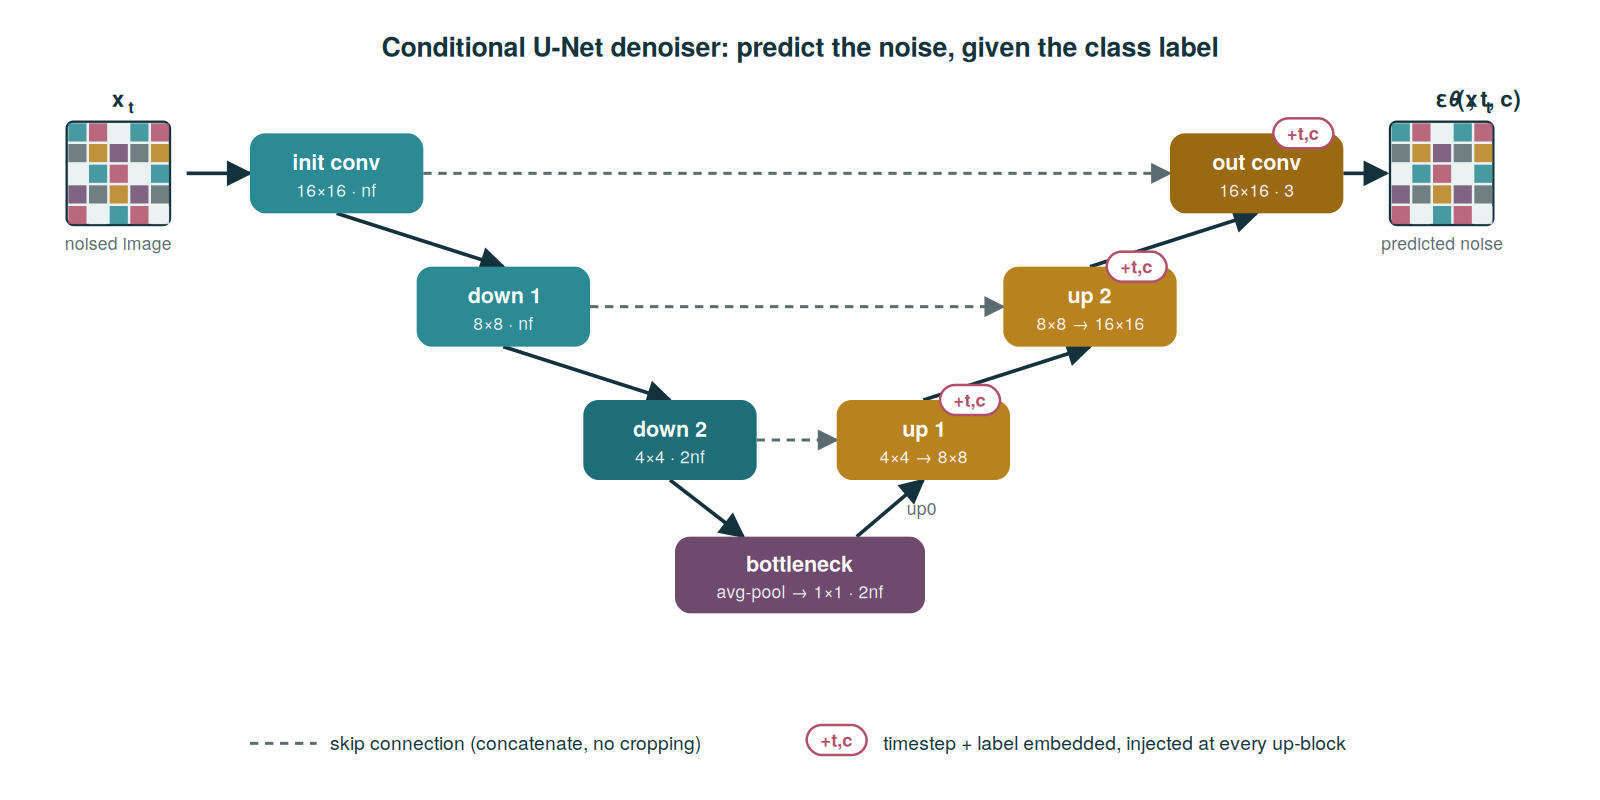<br><span style="font-size:13px; color:#5C6B70;">The conditional U-Net &#949;<sub>&#952;</sub>(x<sub>t</sub>, t, c): same encoder/decoder with skip connections, now with the class label c embedded and injected alongside the timestep at every up-block.</span></p>


In [6]:
class ContextUnet(nn.Module):
    def __init__(self, in_channels, n_feat=256, n_cfeat=10, height=28):  # cfeat - context features
        super(ContextUnet, self).__init__()

        # number of input channels, number of intermediate feature maps and number of classes
        self.in_channels = in_channels
        self.n_feat = n_feat
        self.n_cfeat = n_cfeat
        self.h = height  #assume h == w. must be divisible by 4, so 28,24,20,16...

        # Initialize the initial convolutional layer
        self.init_conv = ResidualConvBlock(in_channels, n_feat, is_res=True)

        # Initialize the down-sampling path of the U-Net with two levels
        self.down1 = UnetDown(n_feat, n_feat)        # down1 #[10, 256, 8, 8]
        self.down2 = UnetDown(n_feat, 2 * n_feat)    # down2 #[10, 256, 4,  4]

         # original: self.to_vec = nn.Sequential(nn.AvgPool2d(7), nn.GELU())
        self.to_vec = nn.Sequential(nn.AvgPool2d((4)), nn.GELU())

        # Embed the timestep and context labels with a one-layer fully connected neural network
        self.timeembed1 = EmbedFC(1, 2*n_feat)
        self.timeembed2 = EmbedFC(1, 1*n_feat)
        self.contextembed1 = EmbedFC(n_cfeat, 2*n_feat)
        self.contextembed2 = EmbedFC(n_cfeat, 1*n_feat)

        # Initialize the up-sampling path of the U-Net with three levels
        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(2 * n_feat, 2 * n_feat, self.h//4, self.h//4), # up-sample
            nn.GroupNorm(8, 2 * n_feat), # normalize
            nn.ReLU(),
        )
        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)

        # Initialize the final convolutional layers to map to the same number of channels as the input image
        self.out = nn.Sequential(
            nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1), # reduce number of feature maps   #in_channels, out_channels, kernel_size, stride=1, padding=0
            nn.GroupNorm(8, n_feat), # normalize
            nn.ReLU(),
            nn.Conv2d(n_feat, self.in_channels, 3, 1, 1), # map to same number of channels as input
        )

    def forward(self, x, t, c=None):
        """
        x : (batch, in_channels, h, w) : input image x_t
        t : (batch, 1)                 : normalized timestep
        c : (batch, n_cfeat)           : one-hot context label
        """
        # x is the input image, c is the context label, t is the timestep, context_mask says which samples to block the context on

        # pass the input image through the initial convolutional layer
        x = self.init_conv(x)
        # pass the result through the down-sampling path
        down1 = self.down1(x)       #[10, 256, 8, 8]
        down2 = self.down2(down1)   #[10, 256, 4, 4]

        # convert the feature maps to a vector and apply an activation
        hiddenvec = self.to_vec(down2)

        # mask out context if context_mask == 1
        if c is None:
            c = torch.zeros(x.shape[0], self.n_cfeat).to(x)

        # embed context and timestep
        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)     # (batch, 2*n_feat, 1,1)
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)
        #print(f"uunet forward: cemb1 {cemb1.shape}. temb1 {temb1.shape}, cemb2 {cemb2.shape}. temb2 {temb2.shape}")


        up1 = self.up0(hiddenvec)
        up2 = self.up1(cemb1*up1 + temb1, down2)  # add and multiply embeddings
        up3 = self.up2(cemb2*up2 + temb2, down1)
        out = self.out(torch.cat((up3, x), 1))
        return out


## Hyperparameters

Same as Part 1, with one new element: `n_cfeat`, the size of the one-hot **context vector** (here 5 sprite classes).


In [7]:
# hyperparameters

# diffusion hyperparameters
timesteps = 500
beta1 = 1e-4
beta2 = 0.02

# network hyperparameters
device = torch.device("cuda:0" if torch.cuda.is_available() else torch.device('cpu'))
n_feat = 64 # 64 hidden dimension feature
n_cfeat = 5 # context vector is of size 5
height = 16 # 16x16 image
save_dir = './weights/'

# training hyperparameters
batch_size = 100
n_epoch = 32
lrate=1e-3

## The noise schedule

Same fixed schedule as Part 1: $\beta_t$ linear, $\alpha_t=1-\beta_t$, $\bar\alpha_t=\prod_{s\le t}\alpha_s$ (with $\bar\alpha_0=1$), used in $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$. We also precompute the posterior weights $c_1,c_2,\tilde\beta_t$.


In [8]:
# ----- DDPM noise schedule (fixed, no learning), same as Part 1 -----
b_t = (beta2 - beta1) * torch.linspace(0, 1, timesteps + 1, device=device) + beta1
a_t = 1.0 - b_t                                   # per-step signal factor alpha_t
ab_t = torch.cumsum(a_t.log(), dim=0).exp()       # cumulative product abar_t
ab_t[0] = 1.0                                     # abar_0 = 1: no noise at the start

# ----- Posterior weights, precomputed from the schedule alone -----
# Exact reverse step given x0:  q(x_{t-1}|x_t,x0) = N(c1(t) x_t + c2(t) x0, beta_tilde_t * I).
# Use abar_{t-1} = abar_t / alpha_t, the consistent cumulative value at every t.
ab_prev = ab_t / a_t                                          # abar_{t-1}
one_minus_ab = 1.0 - ab_t
c1_t = a_t.sqrt() * (1.0 - ab_prev) / one_minus_ab            # trust in current state x_t
c2_t = ab_prev.sqrt() * b_t / one_minus_ab                    # trust in clean target x0
beta_tilde_t = (1.0 - ab_prev) / one_minus_ab * b_t           # exact posterior variance
# index 0 is never used at sampling time (steps run t = T, ..., 1); zero out the 1/0 there
c1_t[0] = 0.0
c2_t[0] = 0.0
beta_tilde_t[0] = 0.0


## Initialize the Conditional U-Net

Now it's time to initialize the **conditional U-Net model**, which we will use as the denoiser inside the diffusion process.

Compared to the previous notebook, we just require one additional argument:

- `n_cfeat`: the number of context features (i.e., number of sprite classes).




In [9]:
# construct model
nn_model = ContextUnet(in_channels=3, n_feat=n_feat, n_cfeat=n_cfeat, height=height).to(device)

### Set up the optimizer

In [10]:

optim = torch.optim.Adam(nn_model.parameters(), lr=lrate)

## Load the dataset

The same sprites as Part 1, now with their class labels (the context $c$), via the `CustomDataset` helper in `diffusion_utilities.py`.


In [11]:
# load dataset like this if you have it in your directory
# dataset = CustomDataset("./sprites_1788_16x16.npy", "./sprite_labels_nc_1788_16x16.npy", transform, null_context=False)

def download_file(url, local_filename):
    with requests.get(url, stream=True) as r:
        r.raise_for_status()
        with open(local_filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    return local_filename

# Build full URLs
base_url = "https://huggingface.co/datasets/a-lancho/genAI-course-sprites/resolve/main/"

sprites_url = base_url + "sprites_1788_16x16.npy"
labels_url = base_url + "sprite_labels_nc_1788_16x16.npy"

# Download to local files
download_file(sprites_url, "sprites.npy")
download_file(labels_url, "labels.npy")

# Now you can use your class as before:
dataset = CustomDataset("sprites.npy", "labels.npy", transform, null_context=False)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=1)

# construct optimizer
optim = torch.optim.Adam(nn_model.parameters(), lr=lrate)


sprite shape: (89400, 16, 16, 3)
labels shape: (89400, 5)


## Forward process (one shot)

Unchanged by conditioning: $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$. The helper accepts a scalar $t$ or a per-image batch.


In [12]:
# Forward process in one shot: corrupt a clean image x0 to noise level t.
def perturb_input(x0, t, eps):
    """
    Apply the forward identity  x_t = sqrt(abar_t) x0 + sqrt(1 - abar_t) eps.
    Accepts t as an int (scalar) or a (B,) tensor of per-image steps.
    """
    a_bar = ab_t[t]                                   # abar_t: scalar or shape (B,)
    if isinstance(a_bar, torch.Tensor) and a_bar.ndim == 1:
        a_bar = a_bar.view(-1, 1, 1, 1)               # per-image broadcast over (B, C, H, W)
    else:
        a_bar = a_bar.view(1, 1, 1, 1)                # scalar broadcast
    return a_bar.sqrt() * x0 + (1.0 - a_bar).sqrt() * eps


## Training: predict the noise, now given a label <a id="training-conditioned"></a>

Same regression as Part 1, with the label passed in: minimize $\|\varepsilon-\varepsilon_\theta(x_t,t,c)\|^2$. On about 10% of examples we zero out $c$ (the `context_mask` line), so the one model also learns the unconditional denoiser — the ingredient classifier-free guidance uses.


In [13]:
# training with context labels
nn_model.train()

for ep in range(n_epoch):
    print(f'epoch {ep}')
    optim.param_groups[0]['lr'] = lrate * (1 - ep / n_epoch)   # linear LR decay

    pbar = tqdm(dataloader, mininterval=2)
    for x0, c in pbar:                          # x0: clean images, c: one-hot labels
        optim.zero_grad()
        x0 = x0.to(device)
        c = c.to(x0)

        # drop the label on ~10% of examples -> also learn the unconditional model
        context_mask = torch.bernoulli(torch.zeros(c.shape[0]) + 0.9).to(device)
        c = c * context_mask.unsqueeze(-1)

        # corrupt to level t in one shot:  x_t = sqrt(abar_t) x0 + sqrt(1 - abar_t) eps
        eps = torch.randn_like(x0)                                   # epsilon ~ N(0, I)
        t = torch.randint(1, timesteps + 1, (x0.shape[0],)).to(device)
        x_t = perturb_input(x0, t, eps)

        # network predicts the injected noise, conditioned on the label
        eps_theta = nn_model(x_t, t / timesteps, c=c)                # eps_theta(x_t, t, c)

        loss = F.mse_loss(eps_theta, eps)                            # || eps - eps_theta ||^2
        loss.backward()
        optim.step()

    # save model periodically
    if ep % 4 == 0 or ep == int(n_epoch - 1):
        if not os.path.exists(save_dir):
            os.mkdir(save_dir)
        torch.save(nn_model.state_dict(), save_dir + f"context_model_{ep}.pth")
        print('saved model at ' + save_dir + f"context_model_{ep}.pth")


epoch 0


100%|██████████| 894/894 [00:05<00:00, 159.83it/s]


saved model at ./weights/context_model_0.pth
epoch 1


100%|██████████| 894/894 [00:05<00:00, 165.42it/s]


epoch 2


...

epoch 30


100%|██████████| 894/894 [00:05<00:00, 164.59it/s]


epoch 31


100%|██████████| 894/894 [00:05<00:00, 163.68it/s]

saved model at ./weights/context_model_31.pth


## The reverse step

Identical to Part 1: recover $\hat x_0$, take the posterior step $c_1(t)\,x_t+c_2(t)\,\hat x_0$, then add the spread. The label is already baked into the noise prediction, so nothing else changes. This notebook uses $\sigma_t^2=\tilde\beta_t$ (Part 1 used $\beta_t$; both are standard).


In [14]:
# One reverse step: recover the guess for x0, take the exact-posterior step, add noise back.
def denoise_add_noise(x_t, t, eps_theta, z=None):
    if z is None:
        z = torch.randn_like(x_t)

    # 1) network's guess of the clean datum (invert the forward identity)
    x0_hat = (x_t - (1.0 - ab_t[t]).sqrt() * eps_theta) / ab_t[t].sqrt()

    # 2) exact reverse mean with the guess plugged in:  c1(t) x_t + c2(t) x0_hat
    mean = c1_t[t] * x_t + c2_t[t] * x0_hat

    # 3) add the reverse-step spread; sigma_t^2 = beta_tilde_t (exact posterior variance)
    #    (for the simpler choice used in Part 1, replace beta_tilde_t[t] with b_t[t])
    sigma_t = beta_tilde_t[t].sqrt()
    return mean + sigma_t * z


## Sample new images with a label <a id="sampling-conditioned"></a>

Run the reverse chain from pure noise, feeding the label $c$ at every step. Set the label to a class and the samples come out as that class.


In [15]:
# Conditional ancestral (DDPM) sampling: feed the label c at every step.
@torch.no_grad()
def sample_ddpm_context(n_sample, context, save_rate=20):
    # start from pure noise:  x_T ~ N(0, I)
    x_t = torch.randn(n_sample, 3, height, height, device=device)
    intermediate = []

    for i in range(timesteps, 0, -1):
        t = torch.full((n_sample, 1), i / timesteps, device=device)    # (B, 1) step input
        z = torch.randn_like(x_t) if i > 1 else torch.zeros_like(x_t)   # no noise at final step

        eps_theta = nn_model(x_t, t, c=context)                        # eps_theta(x_t, t, c)
        x_t = denoise_add_noise(x_t, i, eps_theta, z)

        if i % save_rate == 0 or i == timesteps or i < 8:
            intermediate.append(x_t.detach().cpu().numpy())

    return x_t, np.stack(intermediate)


## Sampling with random contexts

Generate a batch with randomly chosen one-hot labels and animate the denoising with `plot_sample(...)`. Same-context samples should look stylistically similar; rerun for new combinations. (Load pretrained weights to skip training.)


In [16]:
# If you have pretrained weights available, you can load them like this:
# nn_model.load_state_dict(torch.load(f"{save_dir}/context_model_31.pth", map_location=device))
# nn_model.eval()
# print("Loaded in Model")

In [17]:
def load_pth_from_url(url):
    response = requests.get(url)
    response.raise_for_status()
    buffer = BytesIO(response.content)
    state_dict = torch.load(buffer, map_location=device)  # or 'cuda' if available
    return state_dict

In [18]:
model_url = "https://huggingface.co/a-lancho/genAI-course-sprites/resolve/main/context_model_31.pth"

state_dict = load_pth_from_url(model_url)
nn_model.load_state_dict(state_dict)

nn_model.eval()
print("Loaded in Model")

Loaded in Model


/tmp/ipykernel_665821/1134008309.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(buffer, map_location=device)  # or 'cuda' if available


In [19]:
# visualize samples with randomly selected context
plt.clf()
ctx = F.one_hot(torch.randint(0, 5, (32,)), 5).to(device=device).float()
samples, intermediate = sample_ddpm_context(32, ctx)
animation_ddpm_context = plot_sample(intermediate,32,4,save_dir, "ani_run", None, save=False)
HTML(animation_ddpm_context.to_jshtml())

<Figure size 640x480 with 0 Axes>

## Generated samples with a user-chosen context <a id="visualization"></a>

`show_images(...)` arranges a batch in a grid, rescaling pixels from $[-1,1]$ to $[0,1]$ for display.


In [20]:
def show_images(imgs, nrow=2):
    _, axs = plt.subplots(nrow, imgs.shape[0] // nrow, figsize=(4,2 ))
    axs = axs.flatten()
    for img, ax in zip(imgs, axs):
        img = (img.permute(1, 2, 0).clip(-1, 1).detach().cpu().numpy() + 1) / 2
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(img)
    plt.show()

## Sampling with user-defined contexts

Build a one-hot context tensor to pick the class of each sample (e.g. hero `[1,0,0,0,0]`, food `[0,0,1,0,0]`), pass it to `sample_ddpm_context(...)`, and view with `show_images(...)`. Same-class samples should share a look; different classes should look distinct.


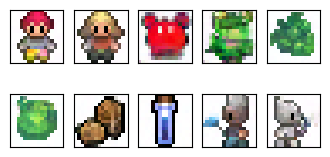

In [21]:
# user defined context
ctx = torch.tensor([
    # hero, non-hero, food, spell, side-facing
    [1,0,0,0,0],
    [1,0,0,0,0],
    [0,1,0,0,0],
    [0,1,0,0,0],
    [0,0,1,0,0],
    [0,0,1,0,0],
    [0,0,0,1,0],
    [0,0,0,1,0],
    [0,0,0,0,1],
    [0,0,0,0,1],
]).float().to(device)
samples, _ = sample_ddpm_context(ctx.shape[0], ctx)
show_images(samples)

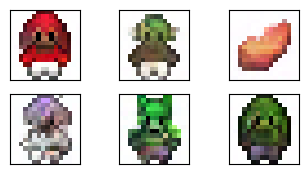

In [22]:
# mix of defined context
ctx = torch.tensor([
    # hero, non-hero, food, spell, side-facing
    [1,0,0,0,0],
    [1,0,0.6,0,0],
    [0,0,0.6,0.4,0],
    [1,0,0,0,1],
    [1,1,0,0,0],
    [1,0,0,1,0]
]).float().to(device)
samples, _ = sample_ddpm_context(ctx.shape[0], ctx)
show_images(samples)

## From conditioning to guidance

The 10% label-dropout above trains the unconditional model alongside the conditional one, which is exactly what **classifier-free guidance** needs: at sampling, combine the two noise predictions,
$$ \tilde\varepsilon = \varepsilon_\theta(x_t,t) + w\,\big[\varepsilon_\theta(x_t,t,c) - \varepsilon_\theta(x_t,t)\big], $$
with $w>1$ amplifying the class. The slides and notes cover classifier and classifier-free guidance.


# Acknowledgments
Sprites by ElvGames, [FrootsnVeggies](https://zrghr.itch.io/froots-and-veggies-culinary-pixels) and  [kyrise](https://kyrise.itch.io/)   
This code is modified from, https://github.com/cloneofsimo/minDiffusion   
Diffusion model is based on [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239) and [Denoising Diffusion Implicit Models](https://arxiv.org/abs/2010.02502)
